In [1]:
def _kf_apply_doc_styles() -> None:
    from pathlib import Path
    import kfactory.utilities
    import kfactory.widgets.interactive

    _lyp = Path('/home/runner/work/kfactory/kfactory/docs/source-built/_static/doc_styles.lyp')
    if not _lyp.is_file():
        return
    _original = kfactory.utilities.as_png_data

    def _styled_as_png_data(c, layer_properties=None, **kwargs):
        return _original(c, layer_properties=layer_properties or str(_lyp), **kwargs)

    kfactory.utilities.as_png_data = _styled_as_png_data
    kfactory.widgets.interactive.as_png_data = _styled_as_png_data


_kf_apply_doc_styles()


# Circular Bends

`bend_circular_factory(kcl)` produces constant-radius arc bends. Unlike euler
bends, `kf.routing.optical.get_radius` returns exactly the nominal radius.
Arguments `width` and `radius` are in **µm**.

In [2]:
import kfactory as kf
from kfactory.factories.circular import bend_circular_factory


class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)


pdk = kf.KCLayout("FACTORIES_CIRCULAR_DEMO", infos=LAYER)
L = LAYER()

circular bend: bend_circular_CS028523d7_500_R10_A90_AS1
footprint radius: 10000 µm (== nominal)


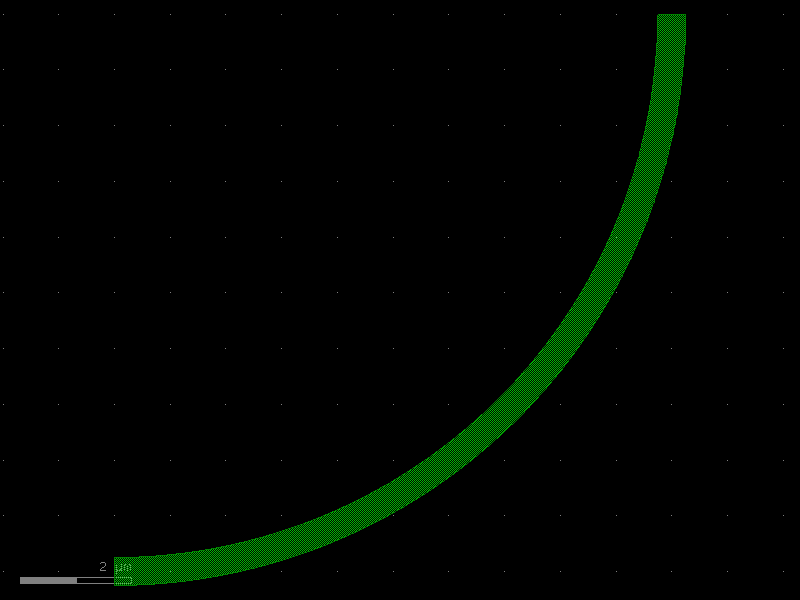

In [3]:
bend_circ = bend_circular_factory(pdk)

bc90 = bend_circ(width=0.5, radius=10.0, layer=L.WG)
print("circular bend:", bc90.name)
print("footprint radius:", kf.routing.optical.get_radius(bc90), "µm (== nominal)")
bc90

## See Also

| Topic | Where |
|-------|-------|